# Sklearn Basics - Polynomial Regression Exercise (SOLUTION)

You have experimental data for heat capacity (Cp) at different temperatures. Your goal is to build a predictive model and compare linear vs polynomial regression.

## Step 1: Import libraries

Import the necessary Python libraries for data analysis and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load the data

Load the heat capacity measurements from the CSV file.

In [2]:
# Load data from 'heat_capacity_data.csv'
df = pd.read_csv('heat_capacity_data.csv')

print(f"Loaded {len(df)} measurements")
print(df.head())

Loaded 80 measurements
   Temperature_K  Cp_J_mol_K
0          300.0       40.25
1          303.8       39.60
2          307.6       41.08
3          311.4       42.70
4          315.2       40.38


## Step 3: Explore the data

Check the data structure and basic statistics.

In [3]:
# Display info
print("Data info:")
print(df.info())

# Display statistics
print("\nStatistics:")
print(df.describe())

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Temperature_K  80 non-null     float64
 1   Cp_J_mol_K     77 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB
None

Statistics:
       Temperature_K  Cp_J_mol_K
count      80.000000   77.000000
mean      450.000000   52.874675
std        88.238658    8.648586
min       300.000000   39.600000
25%       374.975000   45.340000
50%       450.000000   52.050000
75%       525.025000   59.790000
max       600.000000   67.870000


## Step 4: Check for missing values

Identify how many missing values are in the dataset.

In [4]:
# Count missing values
missing = df.isnull().sum()

print("Missing values:")
print(missing)

Missing values:
Temperature_K    0
Cp_J_mol_K       3
dtype: int64


## Step 5: Remove rows with missing values

Clean the data by dropping rows that have missing values.

In [5]:
# Drop rows with any missing values
df_clean = df.dropna()

print(f"Original data: {len(df)} rows")
print(f"Clean data: {len(df_clean)} rows")

Original data: 80 rows
Clean data: 77 rows


## Step 6: Remove outliers

Remove extreme values that are more than 3 standard deviations from the mean.

In [6]:
# Calculate mean and standard deviation of Cp
mean_cp = df_clean['Cp_J_mol_K'].mean()
std_cp = df_clean['Cp_J_mol_K'].std()

# Keep only values within 3 standard deviations
df_clean = df_clean[abs(df_clean['Cp_J_mol_K'] - mean_cp) < 3 * std_cp]

print(f"After removing outliers: {len(df_clean)} rows")

After removing outliers: 77 rows


## Step 7: Separate features and target

Split the data into X (temperature) and y (heat capacity).

In [7]:
# X is the feature (Temperature_K)
X = df_clean[['Temperature_K']].values

# y is the target (Cp_J_mol_K)
y = df_clean['Cp_J_mol_K'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (77, 1)
y shape: (77,)


## Step 8: Split into training and test sets

Divide the data: 80% for training, 20% for testing.

In [8]:
# Split data (test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Training set: 61 samples
Test set: 16 samples


## Step 9: Verify the split

Check that the split worked correctly.

In [9]:
# Calculate percentage in training set
train_percentage = len(X_train) / len(X) * 100

print(f"Training percentage: {train_percentage:.1f}%")
print(f"Test percentage: {100 - train_percentage:.1f}%")

Training percentage: 79.2%
Test percentage: 20.8%


## Step 10: Create polynomial features (Degree 1 - Linear)

First, fit a simple linear model.

In [10]:
# Create polynomial features with degree=1 (linear)
poly1 = PolynomialFeatures(degree=1)

# Transform training data
X_train_poly1 = poly1.fit_transform(X_train)

# Transform test data
X_test_poly1 = poly1.transform(X_test)

# Create and fit linear regression model
model1 = LinearRegression()
model1.fit(X_train_poly1, y_train)

print("Linear model (degree 1) trained!")

Linear model (degree 1) trained!


## Step 11: Create polynomial features (Degree 2)

Fit a quadratic model.

In [11]:
# Create polynomial features with degree=2
poly2 = PolynomialFeatures(degree=2)

# Transform training data
X_train_poly2 = poly2.fit_transform(X_train)

# Transform test data
X_test_poly2 = poly2.transform(X_test)

# Create and fit linear regression model
model2 = LinearRegression()
model2.fit(X_train_poly2, y_train)

print("Quadratic model (degree 2) trained!")

Quadratic model (degree 2) trained!


## Step 12: Create polynomial features (Degree 3)

Fit a cubic model.

In [12]:
# Create polynomial features with degree=3
poly3 = PolynomialFeatures(degree=3)

# Transform training data
X_train_poly3 = poly3.fit_transform(X_train)

# Transform test data
X_test_poly3 = poly3.transform(X_test)

# Create and fit linear regression model
model3 = LinearRegression()
model3.fit(X_train_poly3, y_train)

print("Cubic model (degree 3) trained!")

Cubic model (degree 3) trained!


## Step 13: Make predictions with all models

Use each model to predict heat capacity for the test set.

In [13]:
# Predictions from model 1 (linear)
y_pred1 = model1.predict(X_test_poly1)

# Predictions from model 2 (quadratic)
y_pred2 = model2.predict(X_test_poly2)

# Predictions from model 3 (cubic)
y_pred3 = model3.predict(X_test_poly3)

print("Predictions made for all models!")

Predictions made for all models!


## Step 14: Calculate R² scores

Evaluate how well each model performs.

In [14]:
# Calculate R² for each model
r2_1 = r2_score(y_test, y_pred1)
r2_2 = r2_score(y_test, y_pred2)
r2_3 = r2_score(y_test, y_pred3)

print("Model Performance (R² score):")
print(f"  Linear (degree 1):    {r2_1:.4f}")
print(f"  Quadratic (degree 2): {r2_2:.4f}")
print(f"  Cubic (degree 3):     {r2_3:.4f}")

Model Performance (R² score):
  Linear (degree 1):    0.9554
  Quadratic (degree 2): 0.9627
  Cubic (degree 3):     0.9590


## Step 15: Compare models

Identify which model performs best.

In [15]:
# Find the best R² score
best_r2 = max(r2_1, r2_2, r2_3)

if best_r2 == r2_1:
    best_model = "Linear (degree 1)"
elif best_r2 == r2_2:
    best_model = "Quadratic (degree 2)"
else:
    best_model = "Cubic (degree 3)"

print(f"\nBest model: {best_model}")
print(f"Best R² score: {best_r2:.4f}")


Best model: Quadratic (degree 2)
Best R² score: 0.9627


## Step 16: Create smooth prediction curves

Generate predictions across the full temperature range for plotting.

In [16]:
# Create array of temperatures for smooth curves
T_range = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

# Transform for each polynomial degree
T_poly1 = poly1.transform(T_range)
T_poly2 = poly2.transform(T_range)
T_poly3 = poly3.transform(T_range)

# Get predictions
Cp_pred1 = model1.predict(T_poly1)
Cp_pred2 = model2.predict(T_poly2)
Cp_pred3 = model3.predict(T_poly3)

print("Smooth prediction curves created!")

Smooth prediction curves created!


## Step 17: Plot the results

Visualize the data and all three models. This plot will automatically generate when you run this cell.

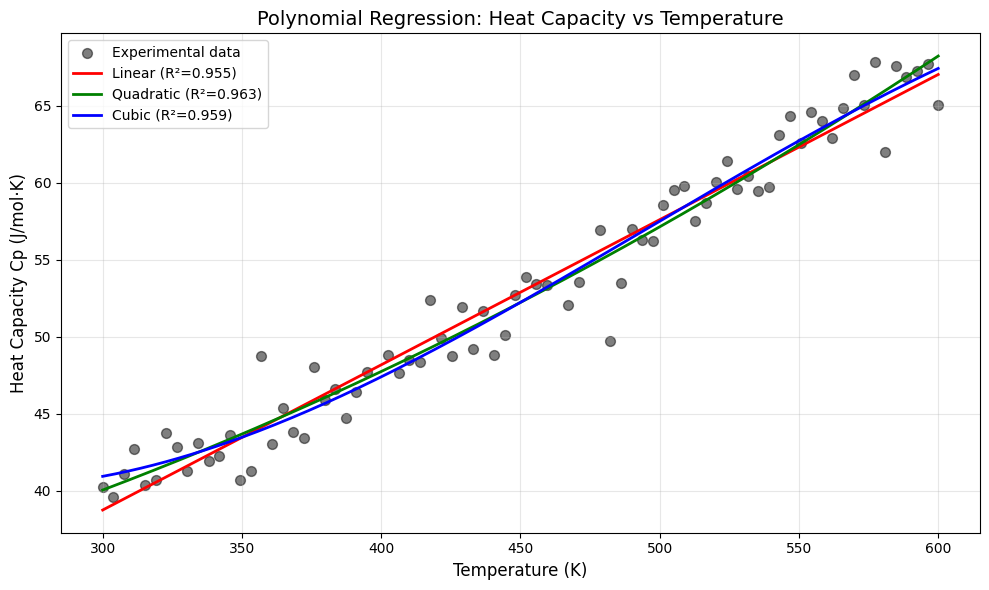


Plot generated successfully!


In [17]:
# Create figure
plt.figure(figsize=(10, 6))

# Plot actual data
plt.scatter(X, y, alpha=0.5, s=50, label='Experimental data', color='black')

# Plot model predictions
plt.plot(T_range, Cp_pred1, 'r-', linewidth=2, label=f'Linear (R²={r2_1:.3f})')
plt.plot(T_range, Cp_pred2, 'g-', linewidth=2, label=f'Quadratic (R²={r2_2:.3f})')
plt.plot(T_range, Cp_pred3, 'b-', linewidth=2, label=f'Cubic (R²={r2_3:.3f})')

# Labels and legend
plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel('Heat Capacity Cp (J/mol·K)', fontsize=12)
plt.title('Polynomial Regression: Heat Capacity vs Temperature', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPlot generated successfully!")

## Step 18: Summary

Review what you've accomplished.

In [18]:
print("=" * 50)
print("ANALYSIS COMPLETE")
print("=" * 50)
print(f"\nData: {len(df_clean)} heat capacity measurements")
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nModel Performance:")
print(f"  Linear:    R² = {r2_1:.4f}")
print(f"  Quadratic: R² = {r2_2:.4f}")
print(f"  Cubic:     R² = {r2_3:.4f}")
print(f"\nBest model: {best_model} (R² = {best_r2:.4f})")
print("\nKey insight: Higher degree polynomials can capture")
print("the non-linear relationship between temperature and Cp.")

ANALYSIS COMPLETE

Data: 77 heat capacity measurements
Training set: 61 samples
Test set: 16 samples

Model Performance:
  Linear:    R² = 0.9554
  Quadratic: R² = 0.9627
  Cubic:     R² = 0.9590

Best model: Quadratic (degree 2) (R² = 0.9627)

Key insight: Higher degree polynomials can capture
the non-linear relationship between temperature and Cp.
